In [1]:
import joblib

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from loguru import logger

pd.set_option("display.max_columns", None)

In [2]:
from src.evaluation import build_predictions_report

In [3]:
def plot_barh_by_model(results_df, x, y="model", hue=None, title="", figsize=(8, 6)):
    """Barplot horizontal genérico para comparar modelos por una métrica."""
    palette = {"ML": "#1f77b4", "Statistical": "#ff7f0e", "Naive": "#2ca02c"}
    df_sorted = results_df.sort_values(x, ascending=True)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(df_sorted, x=x, y=y, hue=hue, hue_order=list(palette.keys()), order=df_sorted[y],
                dodge=False, palette=palette if hue else None, ax=ax)
    ax.set_title(title, loc="left", pad=20)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine()
    if hue:
        ax.legend(title=hue, loc="upper right")
    plt.tight_layout()
    plt.show()

In [4]:
!ls ../artifacts/models/

level_01_daily_total_sales_artifact.pkl  level_04_daily_dept_sales_artifact.pkl


In [5]:
ARTIFACT = "level_04_daily_dept_sales_artifact"

In [6]:
import joblib

from src.data.split import reconstruct_test_data

artifact_path = f"../artifacts/models/{ARTIFACT}.pkl"
artifact = joblib.load(artifact_path)

model = artifact["model"]
FEATURES = artifact["features"]
feature_importance = artifact["feature_importance"]
results_df = artifact["results_df"]

X_test, y_test, artifact["train"], artifact["test"] = reconstruct_test_data(artifact)

2026-08-30 16:10:29.922 | INFO     | src.data.split:load_data:359 - level_04_daily_dept | target=sales | 13,587 filas | 191 features (9 categóricas)
2026-08-30 16:10:29.961 | INFO     | src.data.split:log_summary:48 - Train : 2011-01-29 to 2016-03-27 (1,885 days, 13,195 rows)
2026-08-30 16:10:29.963 | INFO     | src.data.split:log_summary:49 - Valid : 2016-03-28 to 2016-04-24 (28 days, 196 rows)
2026-08-30 16:10:29.964 | INFO     | src.data.split:log_summary:50 - Test  : 2016-04-25 to 2016-05-22 (28 days, 196 rows)
2026-08-30 16:10:30.259 | INFO     | src.data.split:split_data:421 - Features: 140 (3 categóricas)


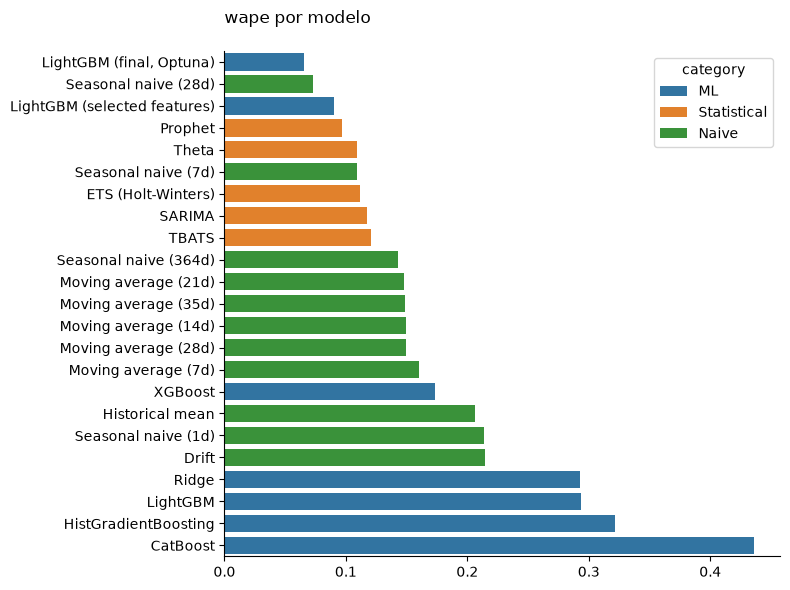

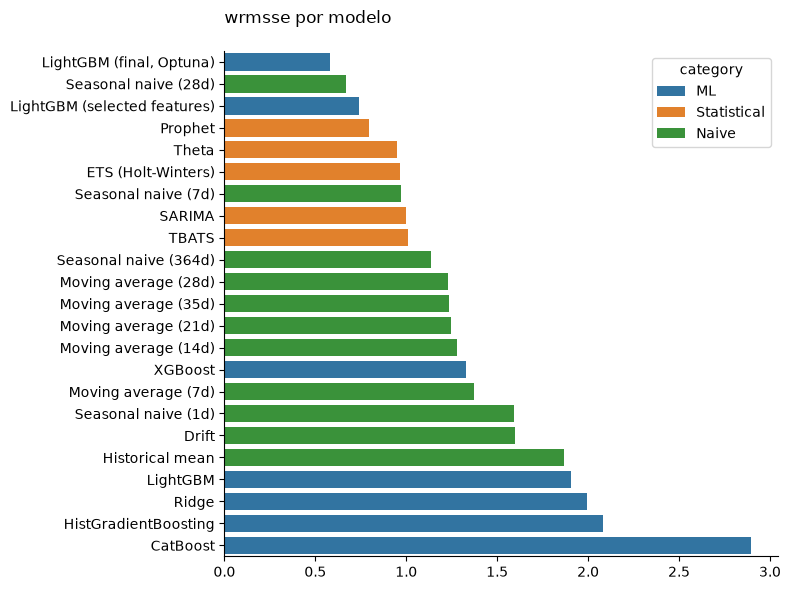

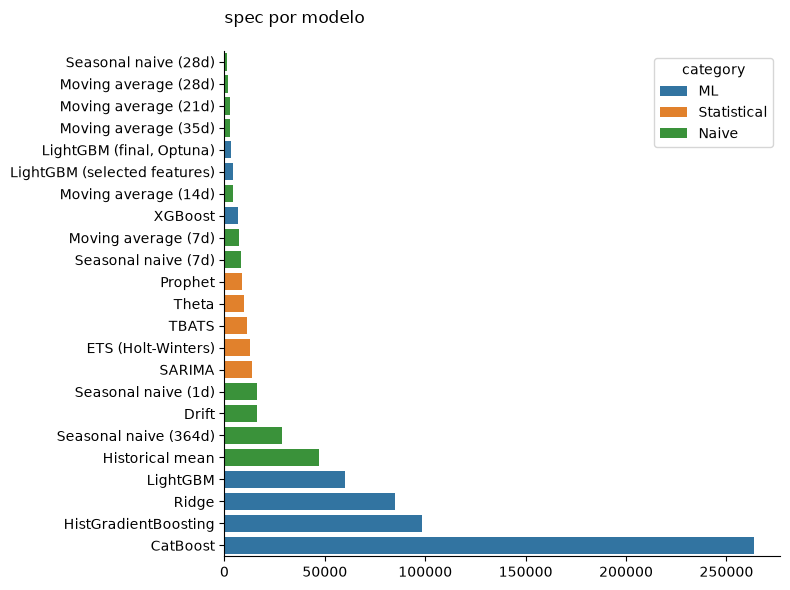

In [7]:
#['wape', 'wrmsse', 'mae', 'rmse', 'mape', 'smape', 'bias', 'rmsle', 'tracking_signal', 'spec', 'mase', 'fit_time']:
for col in ['wape', 'wrmsse', 'spec']:
    plot_barh_by_model(results_df, hue="category", x=col, y="model", title=f"{col} por modelo")

## Explicación modelo

In [8]:
import shap

explainer = shap.TreeExplainer(model)

X_shap = X_test.sample(n=min(300_000, len(X_test)), random_state=42)

shap_values = explainer.shap_values(X_shap)
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns, index=X_shap.index)

importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df)

                             feature  mean_abs_shap
30                   te_weekend_mean    2094.353003
54                             lag28     982.663298
0                            dept_id     923.695438
58                            lag182     112.217796
6                                day      90.594300
..                               ...            ...
71   rolling_mean_lag1_window_size35       0.812510
105   rolling_min_lag6_window_size14       0.722382
99    rolling_max_lag5_window_size14       0.694897
93    rolling_max_lag4_window_size14       0.626486
80    rolling_max_lag2_window_size14       0.144885

[140 rows x 2 columns]


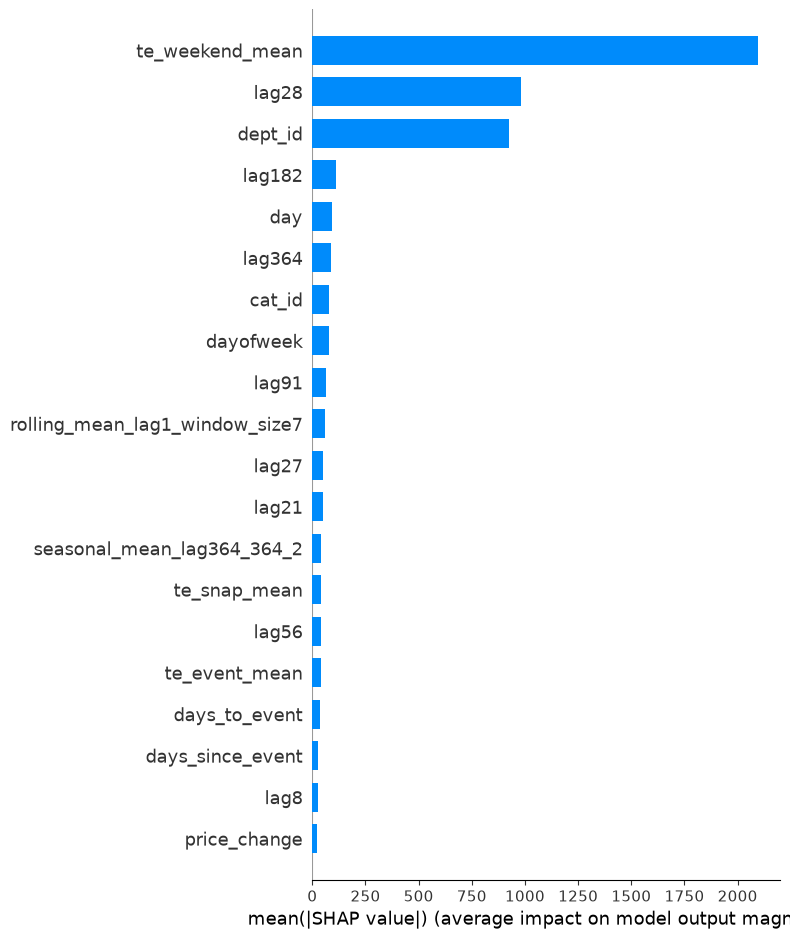

In [9]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

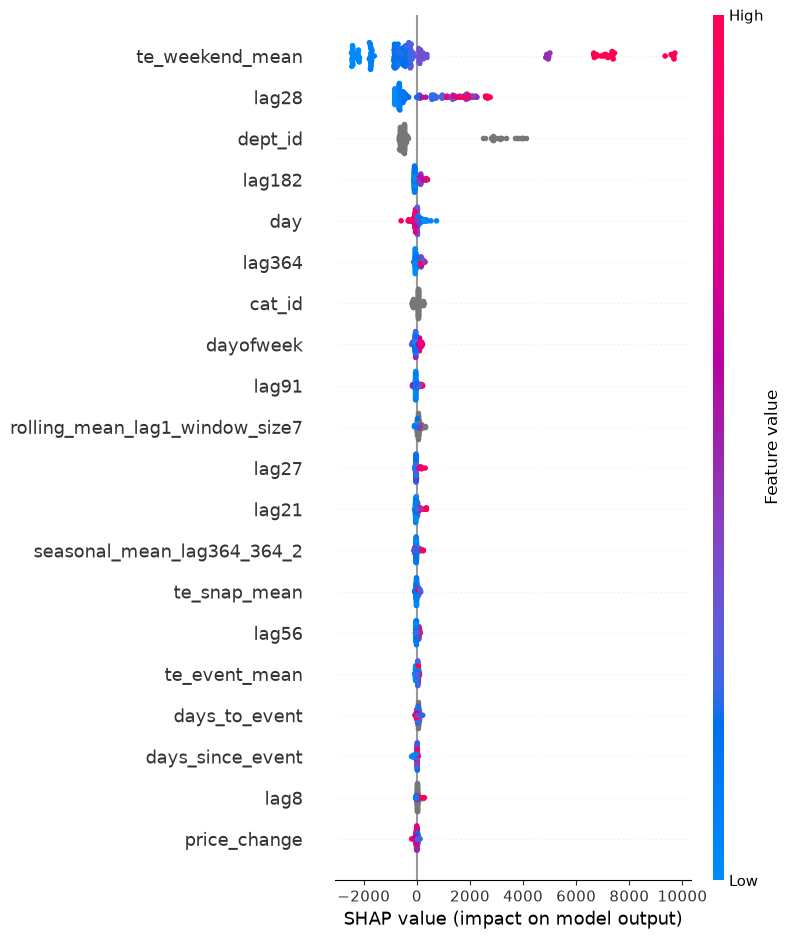

In [10]:
shap.summary_plot(shap_values, X_shap)

# Predicciones

In [11]:
from src.evaluation import analizar_prediccion, plot_forecast, explain_prediction

In [12]:
metrics_test_final, df_pred = build_predictions_report(artifact['train'], artifact['test'], y_test, model.predict(X_test), target_col=artifact['target'])

print(f"Test WAPE: {metrics_test_final['wape']:.2%}")
print(f"Test WRMSSE: {metrics_test_final['wrmsse']:.4f}")

Test WAPE: 6.89%
Test WRMSSE: 0.5835


In [13]:
from src.evaluation import build_series_metrics

df_metrics = build_series_metrics(artifact['train'], df_pred, target_col=artifact['target'], weight_level=["date"])

In [14]:
df_metrics.head(5)

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
series_id,,,,,,,,,,,,,,,
FOODS_3_FOODS,28,28,564926.0,537077.0,27849.0,31839.0,1.379273e+06,0.353571,0.056360,-0.049297,0.069867,24.491096,0.505927,0.512135,8904.696429
HOUSEHOLD_1_HOUSEHOLD,28,28,222327.0,219064.0,3263.0,10779.0,8.708510e+05,0.223239,0.048483,-0.014677,0.060716,8.476111,0.417765,0.441267,528.401786
FOODS_2_FOODS,28,28,165203.0,162277.0,2926.0,10706.0,5.728573e+05,0.146850,0.064805,-0.017712,0.084268,7.652531,0.868186,0.685546,742.526786
HOBBIES_1_HOBBIES,28,28,102554.0,101935.0,619.0,5559.0,4.758871e+05,0.121992,0.054206,-0.006036,0.066165,3.117827,0.423039,0.486149,577.151786
HOUSEHOLD_2_HOUSEHOLD,28,28,61093.0,59681.0,1412.0,3608.0,2.914828e+05,0.074720,0.059058,-0.023112,0.067170,10.957871,0.524117,0.583081,209.178571


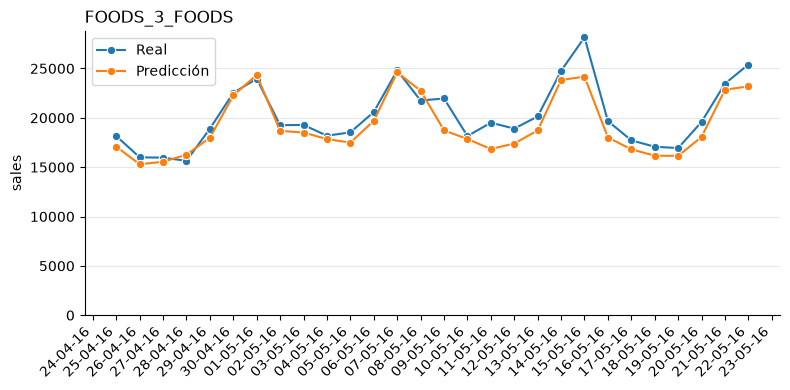

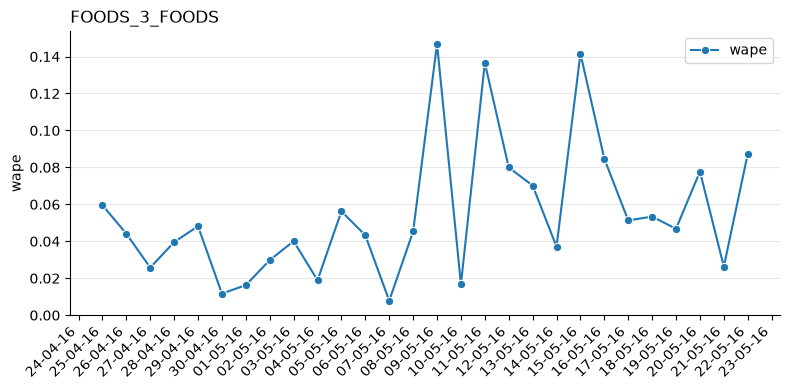

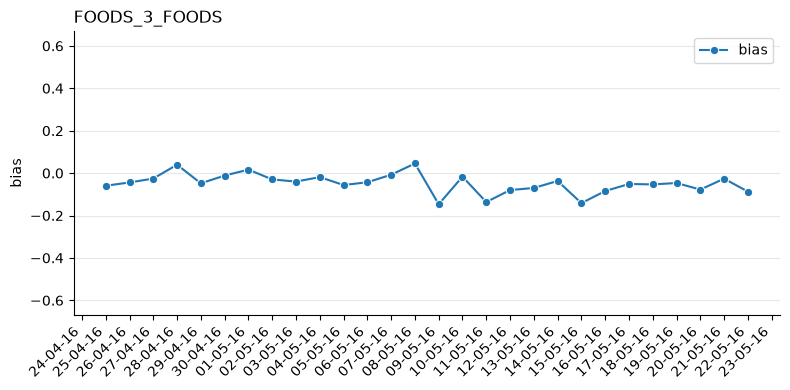

In [15]:
SERIES = 'FOODS_3_FOODS'

top_best_dates = df_pred.query(f'series_id == "{SERIES}"').nsmallest(2, 'wape')['date']
top_error_dates = df_pred.query(f'series_id == "{SERIES}"').nlargest(2, 'wape')['date']

plot_forecast(df_pred, 'sales', series_id=SERIES)
plot_forecast(df_pred, 'wape', series_id=SERIES)
plot_forecast(df_pred, 'bias', series_id=SERIES)

################################################## Date: 2016-05-09 00:00:00 ##################################################


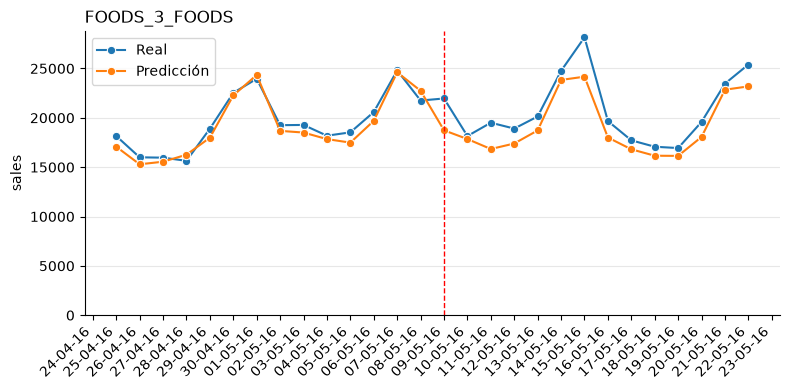

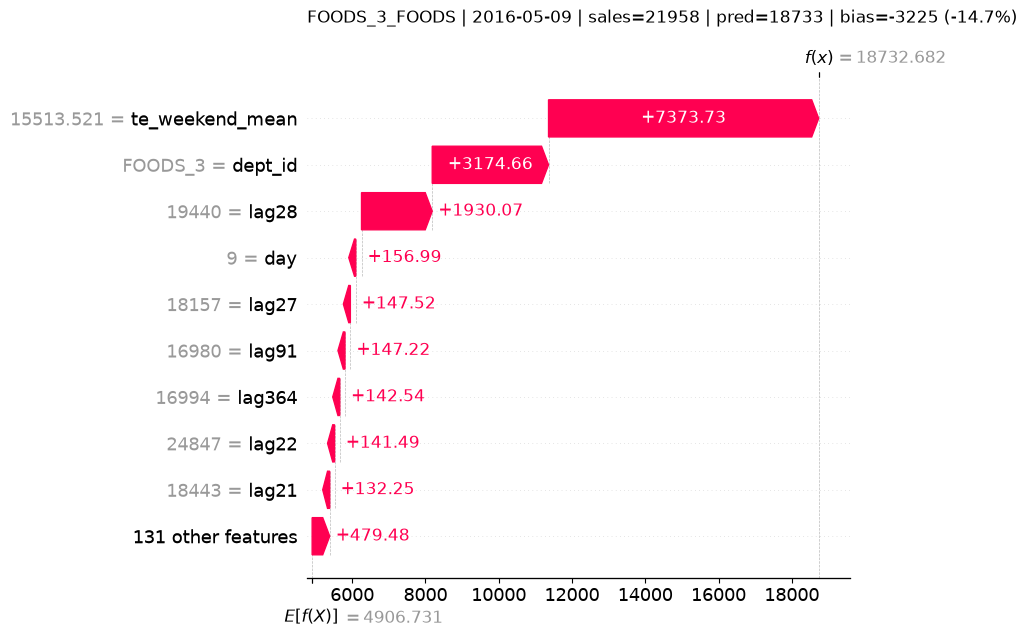

################################################## Date: 2016-05-15 00:00:00 ##################################################


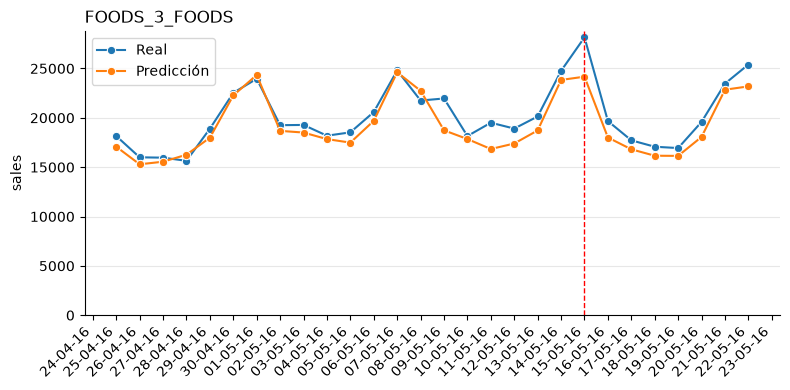

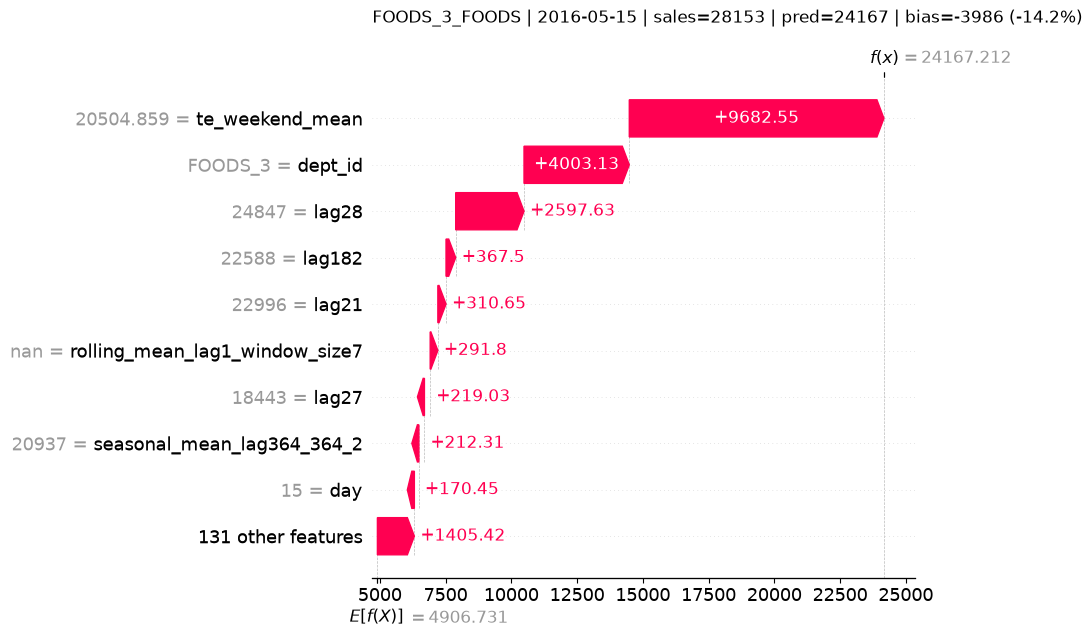

In [16]:
for i in top_error_dates:
    print("#"*50,f"Date: {i}", "#"*50)
    analizar_prediccion(test_df=artifact['test'], X_test=X_test, df_pred=df_pred, target_col=artifact['target'], series_id=SERIES, explainer=explainer, date=i)

################################################## Date: 2016-05-07 00:00:00 ##################################################


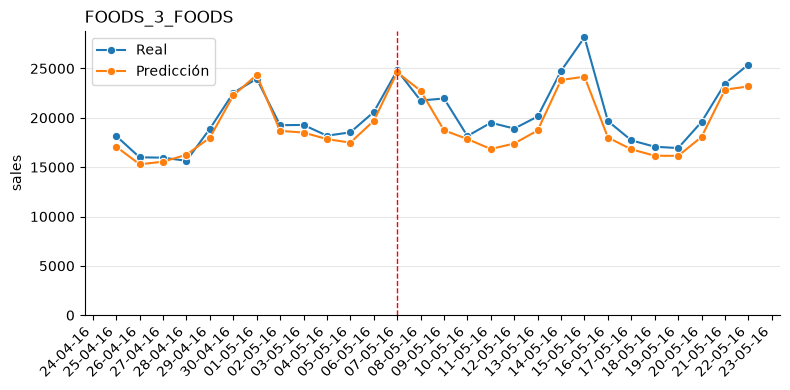

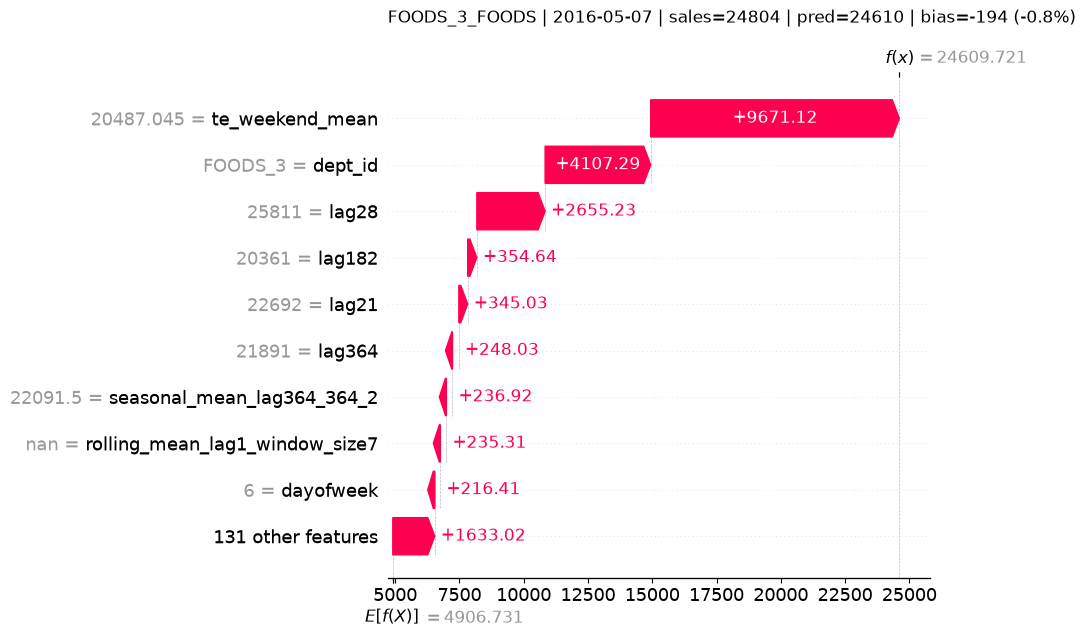

################################################## Date: 2016-04-30 00:00:00 ##################################################


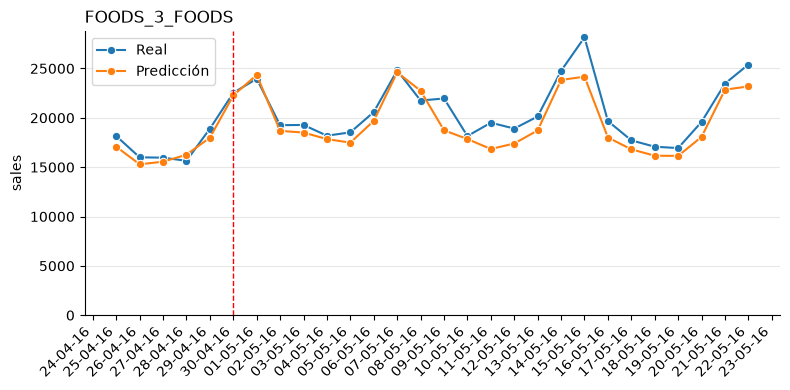

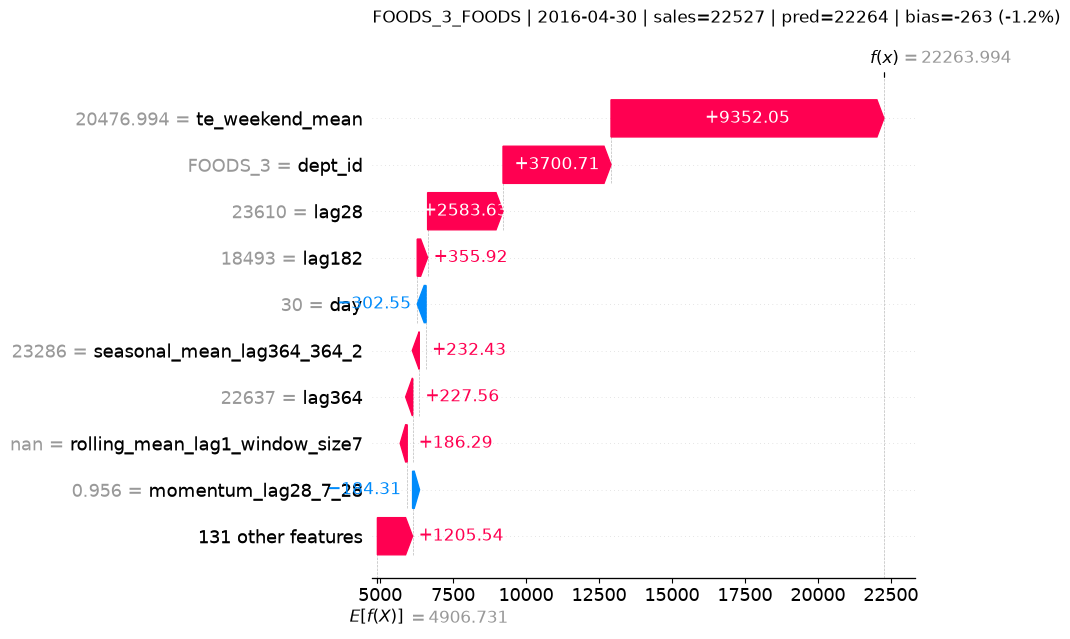

In [17]:
for i in top_best_dates:
    print("#"*50,f"Date: {i}", "#"*50)
    analizar_prediccion(test_df=artifact['test'], X_test=X_test, df_pred=df_pred, target_col=artifact['target'], series_id=SERIES, explainer=explainer, date=i)